In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 10
T = 23/12 #NOTE: changed!
N_SEGS = 12  # must match --n-segs used to build the LHS seed
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)
# # Source
# m1 = 1e6
# m2 = 1e1
# a = 0.7
# p0 = 9
# e0 = 0.4
# xI0 = 1.0
# dist = 4.5
# qS = np.pi
# phiS = 0.
# qK = 0.
# phiK = 0.
# Phi_phi0 = 0.4
# Phi_theta0 = 0.0
# Phi_r0 = 0.5    

# Mojito light EMRI_G
# m1 = 6.72e5
# m2 = 9.84e1
# a = 0.5
# p0 = 15.7117
# e0 = 0.7440
# xI0 = 1.0
# dist = 4.755
# qS = 0.5906
# phiS = 3.5808
# qK = 1.1707
# phiK = 3.8495
# Phi_phi0 = 3.1940
# Phi_theta0 = 3.3780
# Phi_r0 = 0.6038

def icrs_to_ecliptic(qK_icrs, phiK_icrs, eps_deg=23.43929111):
    """
    Convert a sky direction (colatitude, longitude) from the ICRS/equatorial
    frame (qK = pi/2 - dec, phiK = ra) to the ecliptic frame (SSB frame used
    by the LISA response, is_ecliptic_latitude=False convention) via the
    standard equatorial<->ecliptic rotation with J2000 mean obliquity eps.
    """
    dec = np.pi / 2 - qK_icrs
    ra = phiK_icrs
    eps = np.deg2rad(eps_deg)

    sin_beta = np.sin(dec) * np.cos(eps) - np.cos(dec) * np.sin(ra) * np.sin(eps)
    beta = np.arcsin(sin_beta)

    y = np.cos(dec) * np.sin(ra) * np.cos(eps) + np.sin(dec) * np.sin(eps)
    x = np.cos(dec) * np.cos(ra)
    lam = np.arctan2(y, x) % (2 * np.pi)

    qK_ecl = np.pi / 2 - beta
    phiK_ecl = lam
    return qK_ecl, phiK_ecl

# Mojito light EMRI_C
m1 = 3.54e6
m2 = 8.01e1
a = 0.950
p0 = 7.3890
e0 = 0.3160
xI0 = 1.0000
dist = 4.858
qS = 2.0420
phiS = 5.7873
qK, phiK = icrs_to_ecliptic(1.6633, 1.7431)  # catalog qK/phiK are in ICRS, convert to ecliptic
Phi_phi0 = 2.4044
Phi_theta0 = 0.2850
Phi_r0 = 0.9743

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, np.cos(qS), phiS]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i, cos_qS_i, phiS_i = params[i]
        try:
            qS_i = np.arccos(cos_qS_i)
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS_i, phiS_i, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS, phase_max=True))
        except Exception:
            pass
    return out


def prior_transform(u):
    # logm1lim = [5.6,  6.4]
    # logm2lim = [0.8, 1.3]
    # alim = [0.3, 0.99]
    # p0lim = [8.0, 11.0]
    # e0lim = [0.2, 0.5]
    # qSlim = [0.0, np.pi]
    # phiSlim = [0.0, 2 * np.pi]
    # logm1lim = [5.6,  6.4]
    # logm2lim = [1.7, 2.3]
    # alim = [0.3, 0.99]
    # p0lim = [13.5, 16.5]
    # e0lim = [0.6, 0.9]
    # cosqSlim = [-1.0, 1.0]      # cos(qS): source colatitude, sampled uniform in cosine
    # phiSlim = [0.0, 2 * np.pi]

    # EMRI C
    logm1lim = [6.15,  6.95]
    logm2lim = [1.60,  2.20]
    alim = [0.70,  0.999]
    p0lim = [5.89,  8.89]
    e0lim = [0.17,  0.47]
    cosqSlim = [-1.0,  1.0]
    phiSlim = [0.0,  2*np.pi]

    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    t[:, 5] = (cosqSlim[1] - cosqSlim[0]) * u[:, 5] + cosqSlim[0]
    t[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    return t


def inverse_prior_transform(params):
    # EMRI C
    logm1lim = [6.15,  6.95]
    logm2lim = [1.60,  2.20]
    alim = [0.70,  0.999]
    p0lim = [5.89,  8.89]
    e0lim = [0.17,  0.47]
    cosqSlim = [-1.0,  1.0]
    phiSlim = [0.0,  2*np.pi]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (params[:, 5] - cosqSlim[0]) / (cosqSlim[1] - cosqSlim[0])
    u[:, 6] = (params[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    return u

Using dt=10s, T=1.9166666666666667yr, TDI gen=1, N_segs=12
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [ ]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_c/stage1_anneal_s12/'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [4]:
sampler.now_covariances

[array([[ 1.10061687e-10,  1.82629434e-11,  1.82301371e-11,
         -1.08791866e-11, -9.45988606e-11, -6.83114751e-10,
         -1.28714263e-10],
        [ 1.82629434e-11,  1.33946052e-10,  3.28370960e-11,
         -1.97663891e-11, -1.75533253e-10, -1.34822920e-09,
         -2.09021492e-10],
        [ 1.82301371e-11,  3.28370960e-11,  1.33456998e-10,
         -2.03511891e-11, -1.74473806e-10, -1.18134673e-09,
         -2.61867504e-10],
        [-1.08791866e-11, -1.97663891e-11, -2.03511891e-11,
          1.13771816e-10,  1.18255266e-10,  6.44241093e-10,
          2.38691424e-10],
        [-9.45988606e-11, -1.75533253e-10, -1.74473806e-10,
          1.18255266e-10,  1.21454472e-09,  7.75687567e-09,
          1.98209859e-09],
        [-6.83114751e-10, -1.34822920e-09, -1.18134673e-09,
          6.44241093e-10,  7.75687567e-09,  1.43372773e-07,
         -3.95752113e-09],
        [-1.28714263e-10, -2.09021492e-10, -2.61867504e-10,
          2.38691424e-10,  1.98209859e-09, -3.95752113e-09

In [5]:
len(sampler.now_covariances)

1

In [6]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.54859399, 1.90299287, 0.94967512, 7.38999718, 0.31763794,
        0.44874503, 2.67619141]])

In [7]:
log_density(maxld_pt1)

array([119.94188675])

In [8]:
log_density([param_true])

array([123.54490623])

In [9]:
param_ranges = [(6.15,  6.95),
                (1.60,  2.20),
                (0.70,  0.999),
                (5.89,  8.89),
                (0.17,  0.47),
                (-1,1),
                (0.0, 2 * np.pi)
                ]
param_ranges

[(6.15, 6.95),
 (1.6, 2.2),
 (0.7, 0.999),
 (5.89, 8.89),
 (0.17, 0.47),
 (-1, 1),
 (0.0, 6.283185307179586)]

In [10]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0,np.cos(qS),phiS]
param_true

[6.549003262025788,
 1.9036325160842376,
 0.95,
 7.389,
 0.316,
 -0.45395911390155774,
 5.7873]

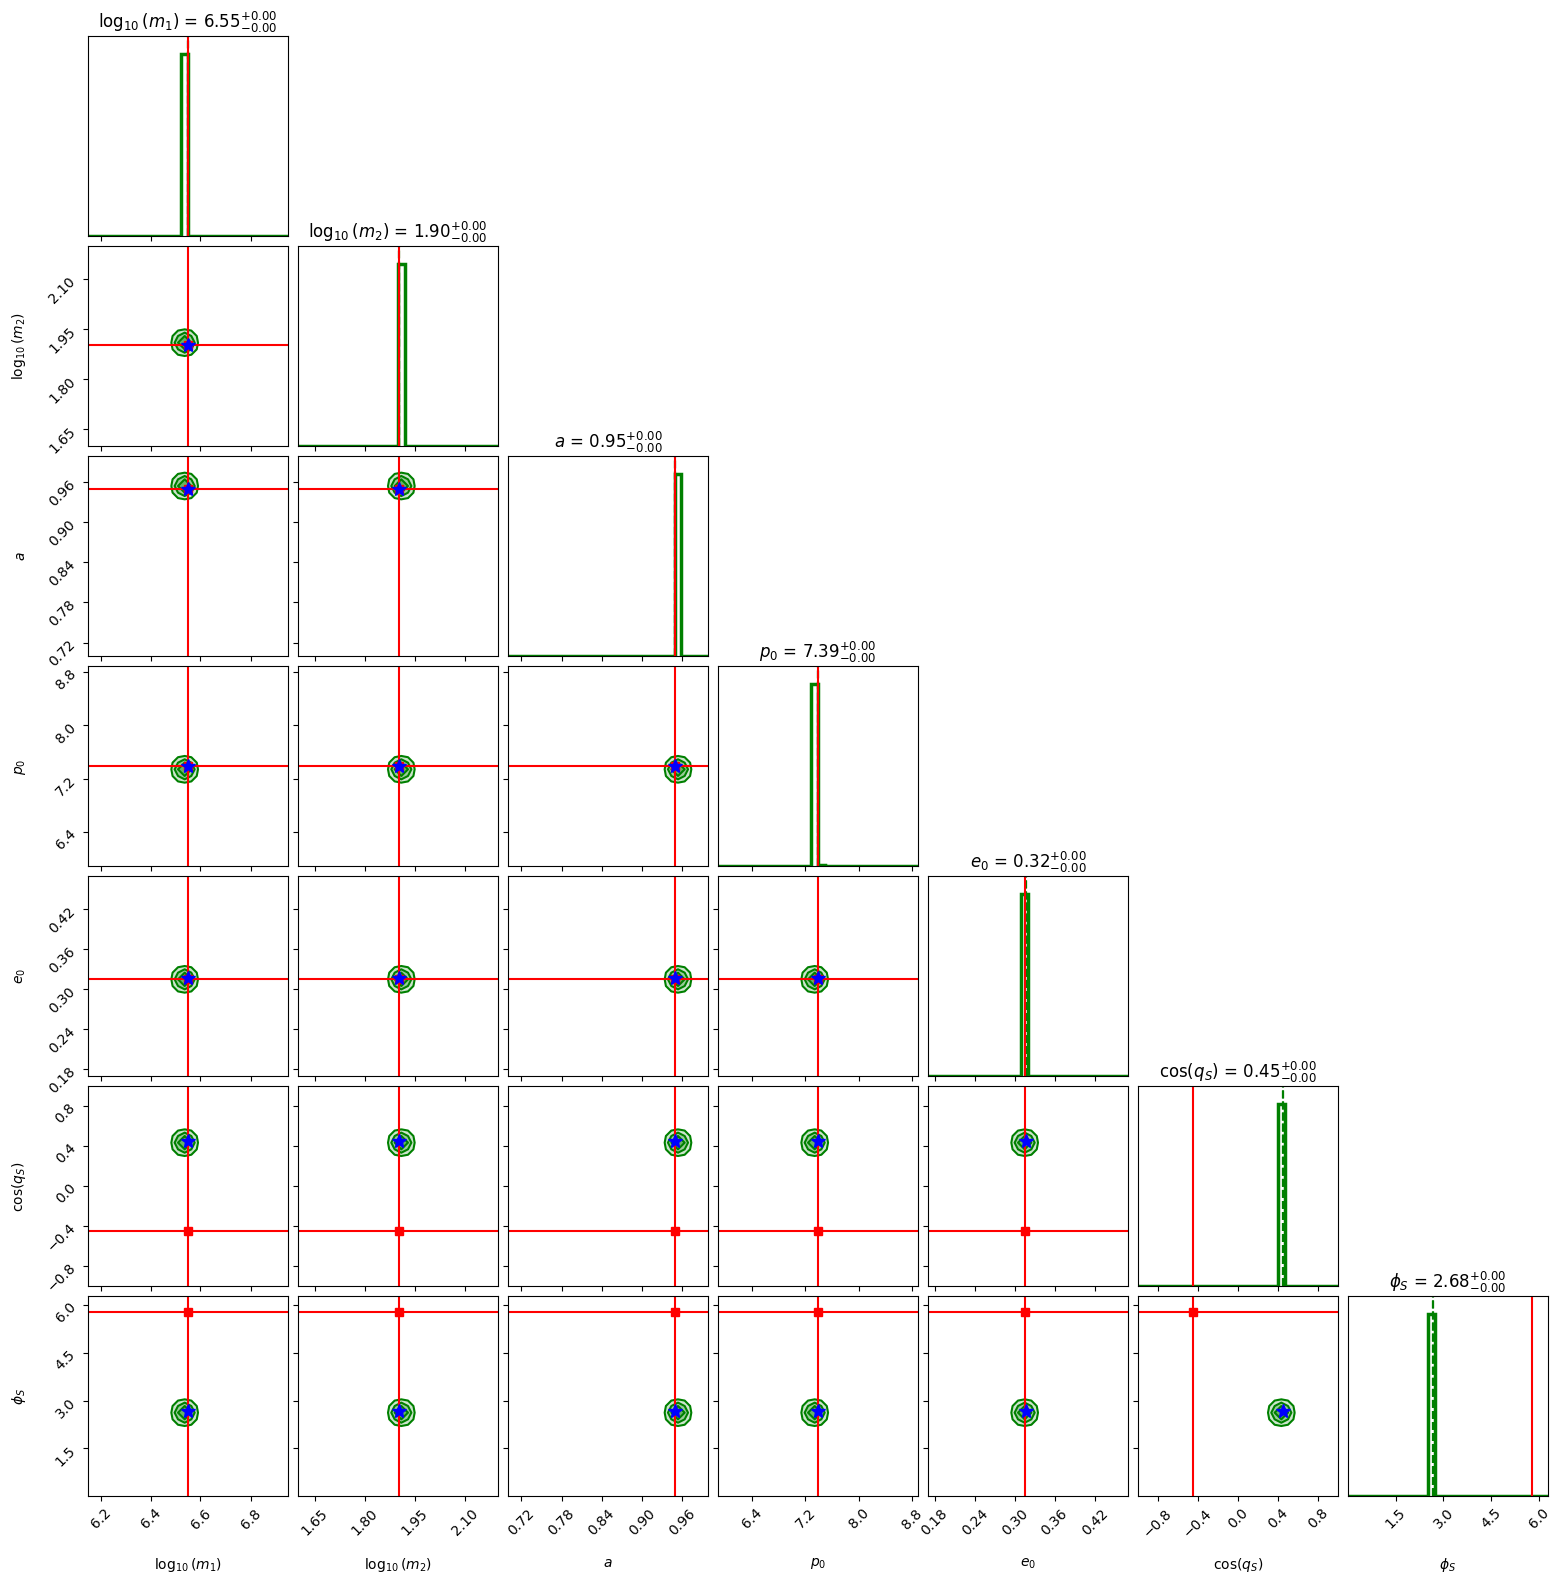

In [11]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$\cos(q_S)$', r'$\phi_S$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)


In [17]:
param_ranges

[(6.15, 6.95),
 (1.6, 2.2),
 (0.7, 0.999),
 (5.89, 8.89),
 (0.17, 0.47),
 (-1, 1),
 (0.0, 6.283185307179586)]

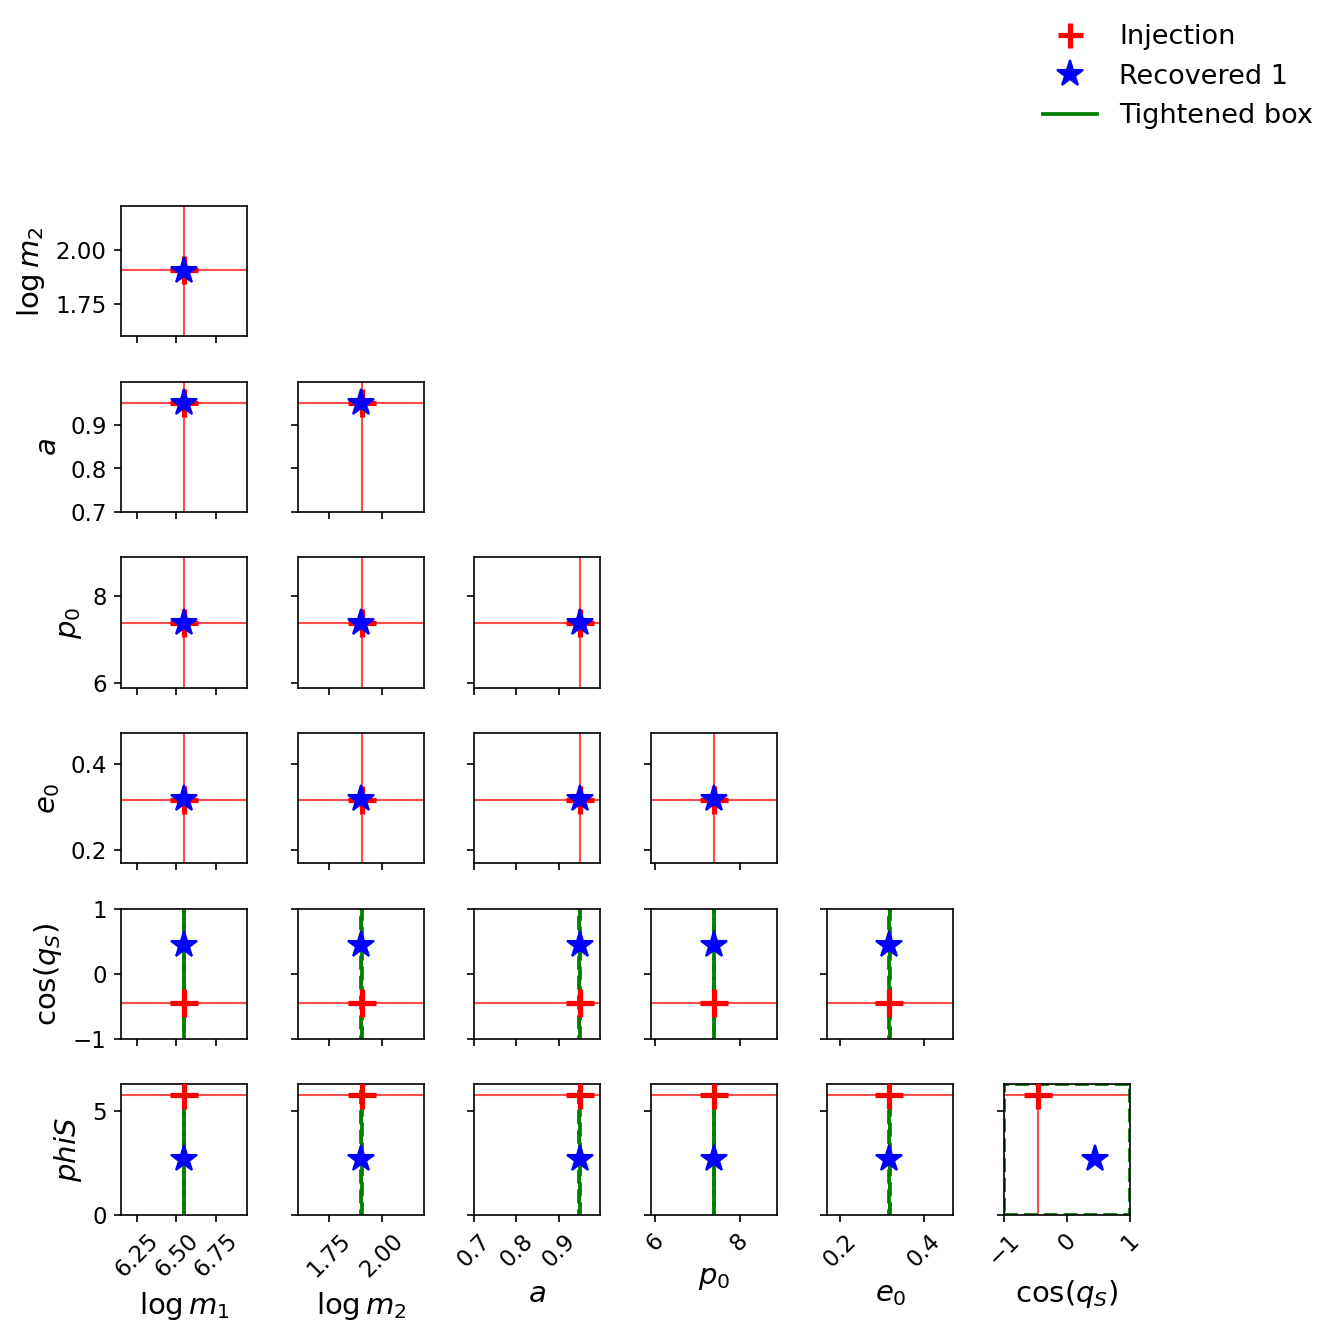

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$\cos(q_S)$', r'$phiS$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

# tightened search box, hard-coded from the printed bounds
box_lo = np.array([6.54808, 1.90229, 0.94932, 7.38774, 0.31562, -1.0,     0.0])
box_hi = np.array([6.54911, 1.90370, 0.95003, 7.39225, 0.31965,  1.0,     2*np.pi])

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP points
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)
        # ax.plot(maxld_pt2[j], maxld_pt2[i], '*', color='orange',
        #         ms=13, zorder=4)

        # tightened box overlay
        ax.add_patch(Rectangle(
            (box_lo[j], box_lo[i]),
            box_hi[j] - box_lo[j],
            box_hi[i] - box_lo[i],
            facecolor='none', edgecolor='green', lw=1.8, zorder=2, linestyle='--',
        ))

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',    marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue',   marker='*', ls='', ms=13,          label='Recovered 1'),
    # Line2D([0], [0], color='orange', marker='*', ls='', ms=13,          label='Recovered 2'),
    Line2D([0], [0], color='green',  lw=1.8,                            label='Tightened box')
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()    

Text(0, 0.5, '$phiS$')

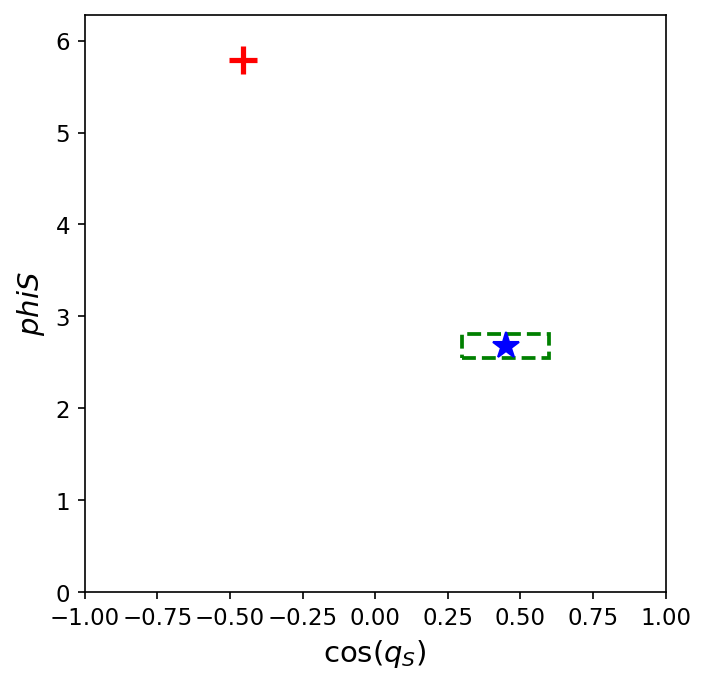

In [18]:
j, i = 5, 6  # cos(qS), phiS
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(param_true[j], param_true[i], '+', color='red', ms=13, mew=2.5)
ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue', ms=13)
ax.add_patch(Rectangle(
    (box_lo[j], box_lo[i]), box_hi[j]-box_lo[j], box_hi[i]-box_lo[i],
    facecolor='none', edgecolor='green', lw=1.8, linestyle='--',
))
ax.set_xlim(*param_ranges[j])
ax.set_ylim(*param_ranges[i])
ax.set_xlabel(r'$\cos(q_S)$'); ax.set_ylabel(r'$phiS$')

# connection plot to proc 1

In [14]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[6.54859399, 1.90299287, 0.94967512, 7.38999718, 0.31763794,
        0.44874503, 2.67619141]])

In [15]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [16]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [17]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


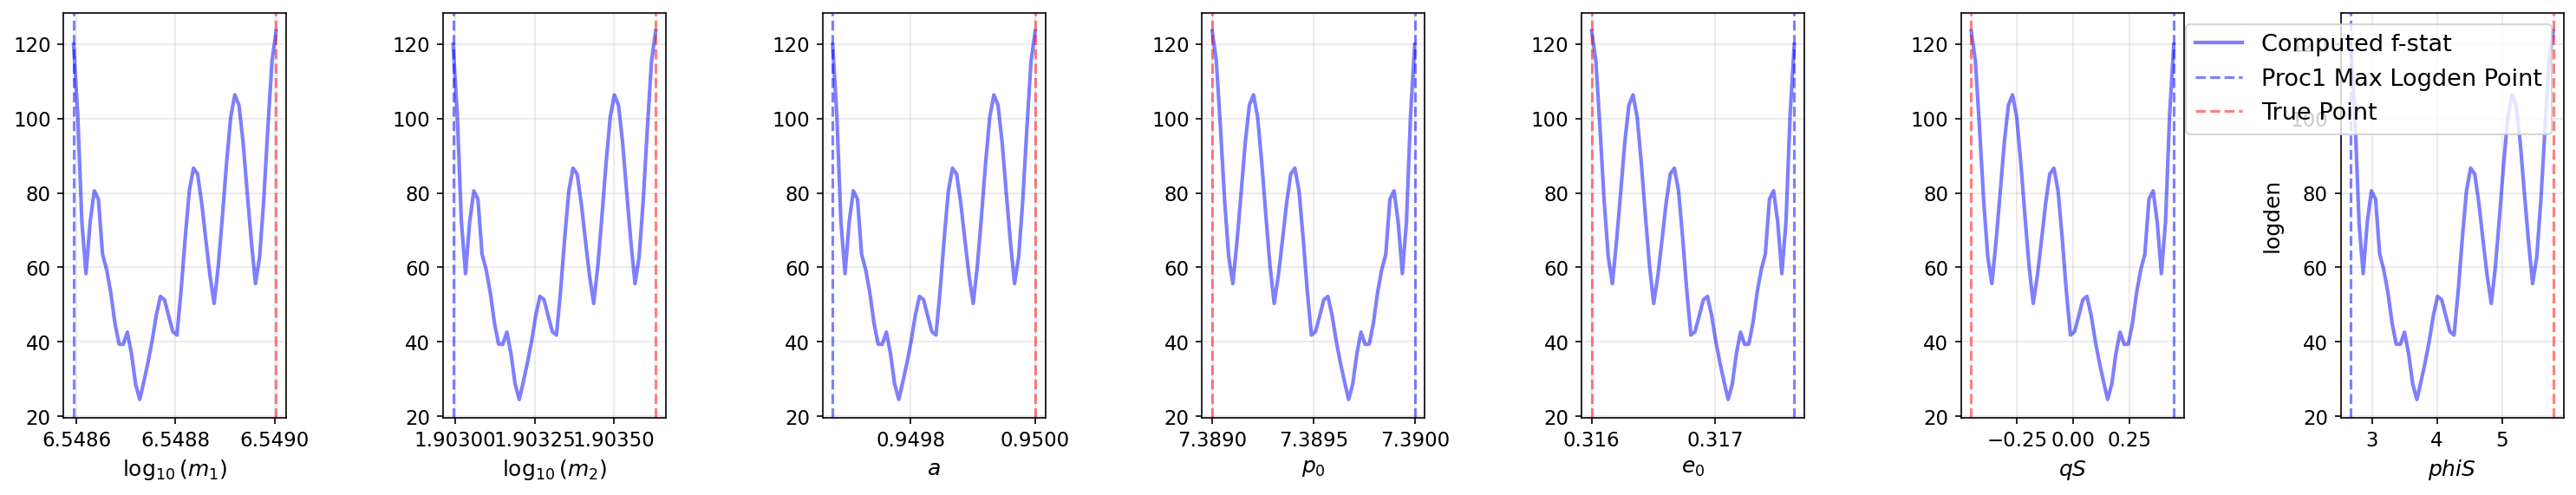

In [18]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [19]:
import numpy as np

def sky_antipode(qS, phiS):
    """
    Antipodal sky point: qS -> pi - qS, phiS -> phiS + pi (mod 2pi).
    qS: colatitude [rad], phiS: azimuth [rad].
    """
    qS_anti = np.pi - qS
    phiS_anti = (phiS + np.pi) % (2 * np.pi)
    return qS_anti, phiS_anti

# EMRI_C true values
qS_true, phiS_true = 2.0420, 5.7873
qS_anti, phiS_anti = sky_antipode(qS_true, phiS_true)

print(f"qS_true={qS_true:.4f}  phiS_true={phiS_true:.4f}  cos(qS_true)={np.cos(qS_true):.5f}")
print(f"qS_anti={qS_anti:.4f}  phiS_anti={phiS_anti:.4f}  cos(qS_anti)={np.cos(qS_anti):.5f}")


qS_true=2.0420  phiS_true=5.7873  cos(qS_true)=-0.45396
qS_anti=1.0996  phiS_anti=2.6457  cos(qS_anti)=0.45396


In [20]:
maxld_pt1

array([6.54859399, 1.90299287, 0.94967512, 7.38999718, 0.31763794,
       0.44874503, 2.67619141])

In [21]:
# Bootstrap-resample the weighted posterior (same as paris3_lhs_s6_ext.py)
weights_norm = weights / weights.sum()
rng_rs = np.random.default_rng(0)
idx_rs = rng_rs.choice(len(samples), size=50_000, replace=True, p=weights_norm)
cov_posterior = np.cov(samples[idx_rs].T)
sigma_diag = np.sqrt(np.diag(cov_posterior))

mu_center = maxld_pt1.ravel()          # max-log-density point (== mu_center in the script)
param_true_arr = np.asarray(param_true).ravel()

n_sigma_needed = (param_true_arr - mu_center) / sigma_diag

param_names = ['logm1', 'logm2', 'a', 'p0', 'e0', 'cos_qS', 'phiS']
for name, mu, sig, ns in zip(param_names, mu_center, sigma_diag, n_sigma_needed):
    print(f'{name:8s}: mu={mu:.5f}  sigma={sig:.5f}  true offset = {ns:+.2f} sigma')

print(f'\nMax |N_sigma| across dims (box would need N_SIGMA >= this to contain truth): '
      f'{np.max(np.abs(n_sigma_needed)):.2f}')

logm1   : mu=6.54859  sigma=0.00000  true offset = +159.02 sigma
logm2   : mu=1.90299  sigma=0.00000  true offset = +181.54 sigma
a       : mu=0.94968  sigma=0.00000  true offset = +185.29 sigma
p0      : mu=7.39000  sigma=0.00001  true offset = -88.44 sigma
e0      : mu=0.31764  sigma=0.00001  true offset = -162.59 sigma
cos_qS  : mu=0.44875  sigma=0.00074  true offset = -1213.08 sigma
phiS    : mu=2.67619  sigma=0.00064  true offset = +4836.71 sigma

Max |N_sigma| across dims (box would need N_SIGMA >= this to contain truth): 4836.71


In [24]:
# Prior bounds (same as paris3_lhs_s6_ext.py / stage1_anneal_s12 prior)
p1_lo = np.array([6.15, 1.60, 0.70, 5.89, 0.17, -1.0, 0.0])
p1_hi = np.array([6.95, 2.20, 0.999, 8.89, 0.47, 1.0, 2 * np.pi])

# N_SIGMA needed to cover the true point (from previous cell), rounded up
N_SIGMA = 200
print(f'N_SIGMA = {N_SIGMA:.0f}')

ellipse_lo = np.clip(mu_center - N_SIGMA * sigma_diag, p1_lo, p1_hi)
ellipse_hi = np.clip(mu_center + N_SIGMA * sigma_diag, p1_lo, p1_hi)
box_width  = ellipse_hi - ellipse_lo
full_width = p1_hi - p1_lo

param_names = ['logm1', 'logm2', 'a', 'p0', 'e0', 'cos_qS', 'phiS']
for name, lo, hi, w, fw in zip(param_names, ellipse_lo, ellipse_hi, box_width, full_width):
    print(f'{name:8s}: [{lo:.5f}, {hi:.5f}]  width={w:.5f}  '
          f'({100*w/fw:.2f}% of full prior width)')

vol_frac = np.prod(box_width / full_width)
print(f'\nBox volume fraction of full prior box: {vol_frac:.3e}  (log10 = {np.log10(vol_frac):.2f})')


N_SIGMA = 200
logm1   : [6.54808, 6.54911]  width=0.00103  (0.13% of full prior width)
logm2   : [1.90229, 1.90370]  width=0.00141  (0.23% of full prior width)
a       : [0.94932, 0.95003]  width=0.00070  (0.23% of full prior width)
p0      : [7.38774, 7.39225]  width=0.00451  (0.15% of full prior width)
e0      : [0.31562, 0.31965]  width=0.00403  (1.34% of full prior width)
cos_qS  : [0.29992, 0.59757]  width=0.29766  (14.88% of full prior width)
phiS    : [2.54755, 2.80484]  width=0.25729  (4.09% of full prior width)

Box volume fraction of full prior box: 8.726e-16  (log10 = -15.06)
